# Análisis Exploratorio

Al realizar la concatenación de los distintos archivos en formato CSV que conforman la GEIH, se obtiene un conjunto de datos de 524 variables y 829.683 filas. Dado que el análisis se realiza con base en la población que afirmó estar ocupada en el año 2024, dicho conjunto se reduce 353.672 filas. 

Luego de realizar una revisión bibliográfica se seleccionaron aquellas variables que diversos autores han señalado como influyentes en la posibilidad de obtener empleo formal, y el numéro de variables es finalmente reducido a 29  (8 cuantitativas y 21 categóricas) en donde se encuentra la variable respuesta "formalidad" cuya construcción fue señalada en la metodología de este trabajo.


In [21]:
#Instalamos librerias
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis
import unidecode

In [3]:
datos = pd.read_csv("/Users/macbook/Downloads/data_filtrada.csv")

Revisaremos si existen datos faltantes en nuestro dataset

In [4]:
print(datos.isnull().sum())

FEX_C18                                                                            0
MES                                                                                0
AREA                                                                          113532
CLASE                                                                              0
DPTO                                                                               0
Sexo                                                                               0
Edad                                                                               0
Parentesco con jefe de hogar                                                       0
¿Usted se reconoce como?                                                           0
Estado civil                                                                       0
¿Afiliado, cotizante o beneficiario de seguridad social en salud?                  0
Régimen de salud al que está afiliado                            

## Porcentaje de variables con datos faltantes

In [5]:

total_filas = len(datos)

faltantes = datos.isnull().sum()
porcentaje_faltantes = (faltantes / total_filas) * 100
tabla_faltantes = pd.DataFrame({
    'Valores Faltantes': faltantes,
    'Porcentaje (%)': porcentaje_faltantes
})

tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores Faltantes'] > 0]
tabla_faltantes = tabla_faltantes.sort_values(by='Porcentaje (%)', ascending=False)

print(tabla_faltantes)


                                                    Valores Faltantes  \
¿El contrato es a término indefinido o fijo?                   214317   
Ofrece sus servicios o productos para                          193533   
¿Quién paga por la afiliación en salud?                        168219   
Medio para conseguir este empleo                               166241   
¿El contrato es verbal o escrito?                              140428   
AREA                                                           113532   
Meses que estuvo sin empleo entre su trabajo ac...              97606   
Tiempo de desplazamiento hasta su sitio de trabajo              50541   
Ingresos laborales                                              15120   
Régimen de salud al que está afiliado                           14347   
Estrato para tarifa                                              1975   
La vivienda ocupada por este hogar es                            1762   

                                                  

Las variables categóricas cuyo porcentaje de valores nulos fue cercano a cero, fueron imputadas por su moda y la función polyreg (Polynomial Regression) del software R. Por su parte, las variables númericas fueron imputadas por su mediana o por la función "norm.predict" (imputación por regresión). A continuación se muestra el encabezado de este conjunto de datos sin la presencia de datos nulos.
Obteniendo así un nuevo conjunto de datos.

In [3]:
datos2 = pd.read_csv("/Users/macbook/Downloads/data_filtrada_imputada.csv")

/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


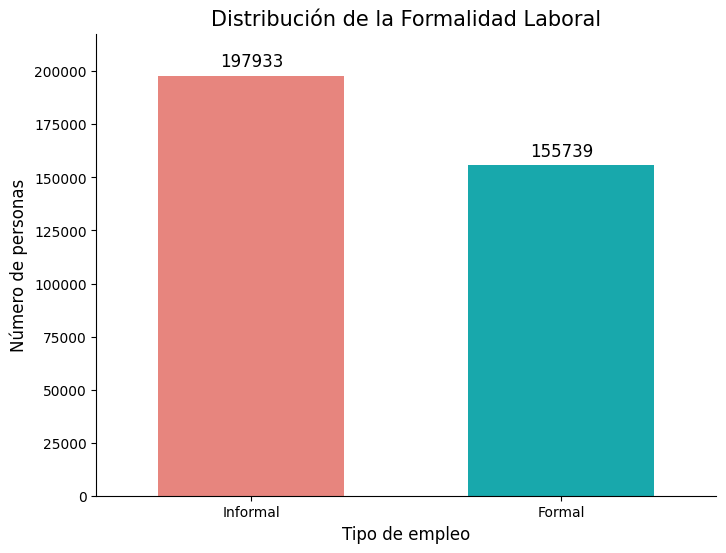

In [ ]:

mapeo_formalidad = {0: 'Informal', 1: 'Formal'}
datos3 = datos2.copy() 
datos3['formalidad'] = datos3['formalidad'].map(mapeo_formalidad)

df_formalidad = datos3['formalidad'].value_counts().reset_index()
df_formalidad.columns = ['formalidad', 'n']
colores = {'Informal': '#F8766D', 'Formal': '#00BFC4'}

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=df_formalidad,
    x='formalidad',
    y='n',

    palette=colores,
    width=0.6
)

# Añadir etiquetas de texto
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=12)

# Personalización
plt.title("Distribución de la Formalidad Laboral", fontsize=15)
plt.xlabel("Tipo de empleo", fontsize=12)
plt.ylabel("Número de personas", fontsize=12)

# Ajustar el límite del eje Y
max_n = df_formalidad['n'].max()
plt.ylim(0, max_n * 1.1)

sns.despine(left=False, bottom=False)
plt.show()

La población ocupada se dedica principalmente a actividades informales como se observa en la anterior gráfica. Se afirma a partir de estos resultados que un 55,9% de los ocupados en Colombia fueron informales, mientras que un 44,1% de los trabajadores gozaban de protección social.

In [11]:
datos2['formalidad'] = pd.to_numeric(datos2['formalidad'], errors='coerce')

## Calcular porcentaje de informalidad por AREA 

In [13]:

df_informal_area = datos2.groupby('AREA').agg(
    total=('formalidad', 'size'),  
    informales=('formalidad', lambda x: (x == 0).sum())  
).reset_index()


df_informal_area['porcentaje_informal'] = (df_informal_area['informales'] / df_informal_area['total']) * 100


df_informal_area = df_informal_area.sort_values(
    by='porcentaje_informal', ascending=False
)

print(df_informal_area.head())

          AREA  total  informales  porcentaje_informal
19   Sincelejo  13290        9146            68.818661
17    Riohacha  11223        7677            68.404170
6    Cúcuta AM  15531       10275            66.158007
21  Valledupar  12086        7952            65.795135
11    Montería  12907        8280            64.151236


/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


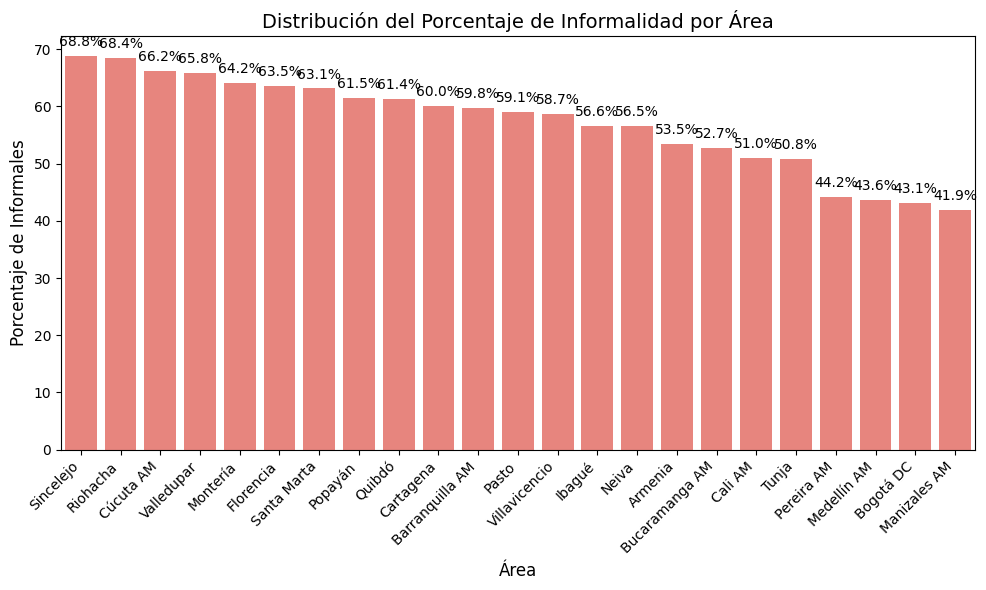

In [14]:

plt.figure(figsize=(10, 6))


order_area = df_informal_area['AREA']

ax = sns.barplot(
    data=df_informal_area,
    x='AREA',
    y='porcentaje_informal',
    order=order_area,  
    color='#F8766D'  
)


for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        xytext=(0, 5),  
        textcoords='offset points',
        fontsize=10
    )


plt.title("Distribución del Porcentaje de Informalidad por Área", fontsize=14)
plt.xlabel("Área", fontsize=12)
plt.ylabel("Porcentaje de Informales", fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.tight_layout() 
plt.show()

Dentro de las ciudades que reportaron las más altas tasas de informalidad se encuentran Sincelejo (68,8%), Riohacha (68,4%) y Cúcuta (66,2%). Mientra que las ciudades con menores tasas de informalidad (y por consiguiente quienes tiene mayor proporción de trabajadores formalizados) fueron Medellín (43,6%), Bogotá (43,1%) y Manizales (41,9%)

En la siguiente tabla se muestra el resumen estadístico de las variables cuantitativas que caracterizaron a la probación ocupada en Colombia en el 2024. En esta tabla se puede observar, por ejemplo, que el promedio de edad de las personas ocupadas en Colombia es 41.71 años con una desviación estándar de 14.09 años. El tiempo promedio de meses que estuvo sin empleo una persona entre su trabajo actual y el anterior es de aproximadamente 4 meses con una desviación estándar de 11 meses. Por otro lado el tiempo medio que una persona tarde en desplazarse hasta su lugar de trabajo es de 24 minutos con una desviación estándar de 21 minutos.

In [15]:

datos_df = datos2.copy()


excluir = ["FEX_C18", "MES", "formalidad"]


num_vars = [
    col for col in datos_df.columns
    if datos_df[col].dtype in ['int64', 'float64', 'int32', 'float32']
    and col not in excluir
]


tablas_por_variable = []

for var in num_vars:
    variable = datos_df[var]

    
    resumen = {
        'Variable': var,
        'Media': variable.mean(),
        'Desviación_Estándar': variable.std(),
        'Mediana': variable.median()
    }
    
   
    tablas_por_variable.append(pd.DataFrame([resumen]))

for tabla in tablas_por_variable:
    print(tabla.to_string(index=False)) 
    print("\n----------------------------------------\n")



Variable     Media  Desviación_Estándar  Mediana
    Edad 41.719248            14.099505     40.0

----------------------------------------

                                                                  Variable     Media  Desviación_Estándar  Mediana
¿Cuánto tiempo lleva en esta empresa trabajando de forma continua (meses)? 83.861103           111.720294     36.0

----------------------------------------

                                                         Variable    Media  Desviación_Estándar  Mediana
Meses que estuvo sin empleo entre su trabajo actual y el anterior 4.024367            11.058771      1.0

----------------------------------------

                                          Variable     Media  Desviación_Estándar  Mediana
Tiempo de desplazamiento hasta su sitio de trabajo 23.744973            21.983194     20.0

----------------------------------------

          Variable        Media  Desviación_Estándar   Mediana
Ingresos laborales 1.653886e+06         2.262

En la anterior tabla se muestra el resumen estadístico de las variables cuantitativas que caracterizaron a la probación ocupada en Colombia en el 2024. En esta tabla se puede observar, por ejemplo, que el promedio de edad de las personas ocupadas en Colombia es 41.71 años con una desviación estándar de 14.09 años. El tiempo promedio de meses que estuvo sin empleo una persona entre su trabajo actual y el anterior es de aproximadamente 4 meses con una desviación estándar de 11 meses. Por otro lado el tiempo medio que una persona tarde en desplazarse hasta su lugar de trabajo es de 24 minutos con una desviación estándar de 21 minutos.

In [19]:


variables_clave_original = [
    "Edad",
    "Ingresos laborales",
    "¿Cuánto tiempo lleva en esta empresa trabajando de forma continua (meses)?",
    "Meses que estuvo sin empleo entre su trabajo actual y el anterior",
    "Tiempo de desplazamiento hasta su sitio de trabajo",
    "Número de cuartos",
    "Número de hogares en la vivienda",
    "Total de personas en el hogar"
]


variables_clave = list(set(variables_clave_original) & set(datos2.columns))




resultados = pd.DataFrame(columns=['Variable', 'Skewness', 'Kurtosis'])


for var in variables_clave:
    
    x = datos2[var]
    skew_val = skew(x, nan_policy='omit')
    kurt_val = kurtosis(x, nan_policy='omit') 

    
    skew_rounded = round(skew_val, 2)
    kurt_rounded = round(kurt_val, 2)

    
    nueva_fila = pd.DataFrame([{'Variable': var, 'Skewness': skew_rounded, 'Kurtosis': kurt_rounded}])
    resultados = pd.concat([resultados, nueva_fila], ignore_index=True)




print(resultados.to_string(index=False))

/var/folders/83/zn8x0yz50rd407m55phbdf5h0000gp/T/ipykernel_18159/727567848.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultados = pd.concat([resultados, nueva_fila], ignore_index=True)


                                                                  Variable  Skewness  Kurtosis
         Meses que estuvo sin empleo entre su trabajo actual y el anterior      5.63     37.82
                                          Número de hogares en la vivienda     12.52    203.78
                                                        Ingresos laborales     13.51    396.79
                                                         Número de cuartos      9.89    767.62
                                             Total de personas en el hogar      1.31      4.37
                        Tiempo de desplazamiento hasta su sitio de trabajo      4.33     34.05
                                                                      Edad      0.36     -0.63
¿Cuánto tiempo lleva en esta empresa trabajando de forma continua (meses)?      2.07      4.55


Pruebas estadísticas de normalidad como Shapiro-Wilk o Kolmogorov-Smirnov pueden ser no adecuadas dado el tamaño de la muestra del presente trabajo. En este caso se utiliza una medida descriptiva como los contrastes de asimetría y curtosis que, según Álvarez et al. (2006) ayudan a determinar si la forma de la distribución de las observaciones muestrales se aleja significativamente de la de un modelo normal en cuanto a su simetría y curtosis. Si una variable aleatoria sigue una distribución normal, ambos coeficientes son nulos (0). Con base en los resultado mostrados en la tabla anterior, Edad parecería ser la única variable que podría seguir una distribución normal.

/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


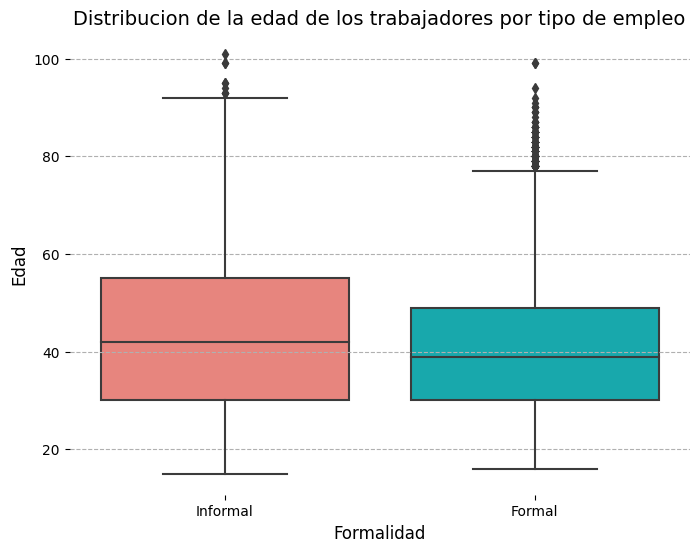

In [25]:
titulo_original = "Distribución de la edad de los trabajadores por tipo de empleo"
titulo = unidecode.unidecode(titulo_original) 


mapeo_formalidad = {0: 'Informal', 1: 'Formal'}
datos2['formalidad_etiqueta'] = datos2['formalidad'].map(mapeo_formalidad)

colores = ['#F8766D', '#00BFC4']


plt.figure(figsize=(8, 6))


ax = sns.boxplot(
    data=datos2,
    x='formalidad_etiqueta',
    y='Edad',
    palette=colores,
    order=['Informal', 'Formal']
)


plt.title(titulo, fontsize=14)
plt.xlabel("Formalidad", fontsize=12)
plt.ylabel("Edad", fontsize=12)


sns.despine(trim=True, left=True, bottom=True)
plt.grid(axis='y', linestyle='--')

plt.show()

Al analizar, por ejemplo, la edad del ocupado en función de si es formal o informal se ha encontrado que existe mayor variabilidad en la edad dentro del grupo de informales en comparación con los formales. No existen grandes diferencias entre la edad mediana de ambos grupos, y se evidencia presencia de outliers en ambas categorías con mayor cantidad dentro de los formales.

Para afirmar con certeza si existen diferencias entre la edad de los trabajadores de ambos grupos se aplica la prueba no paramétrica de Mann-Whitney-Wilcoxon. Entonces, se tiene que: H0: No hay diferencia en la distribución de la edad en trabajadores formales e informales. H1 Existen diferencias en la distribución de la edad en trabajadores formales e informales.

In [26]:

from scipy.stats import mannwhitneyu

edad_informal = datos3.loc[datos3['formalidad'] == 'Informal', 'Edad'].dropna().values
edad_formal = datos3.loc[datos3['formalidad'] == 'Formal', 'Edad'].dropna().values


statistic, p_value = mannwhitneyu(
    edad_informal,
    edad_formal,
    alternative='two-sided'
)
alpha = 0.05

print(f"Resultado de la Prueba de Mann-Whitney U (Edad por Formalidad)")
print("-" * 50)
print(f"Estadístico U: {statistic:.4f}")
print(f"Valor p: {p_value:.6f}")

if p_value < alpha:
    print("\nConclusión: Se rechaza la hipótesis nula (p < 0.05).")
    print("Existe una diferencia estadísticamente significativa en la distribución de la Edad entre los trabajadores formales e informales.")
else:
    print("\nConclusión: No se rechaza la hipótesis nula (p > 0.05).")
    print("No hay evidencia suficiente para afirmar una diferencia significativa en la distribución de la Edad.")

Resultado de la Prueba de Mann-Whitney U (Edad por Formalidad)
--------------------------------------------------
Estadístico U: 16709072715.0000
Valor p: 0.000000

Conclusión: Se rechaza la hipótesis nula (p < 0.05).
Existe una diferencia estadísticamente significativa en la distribución de la Edad entre los trabajadores formales e informales.


/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


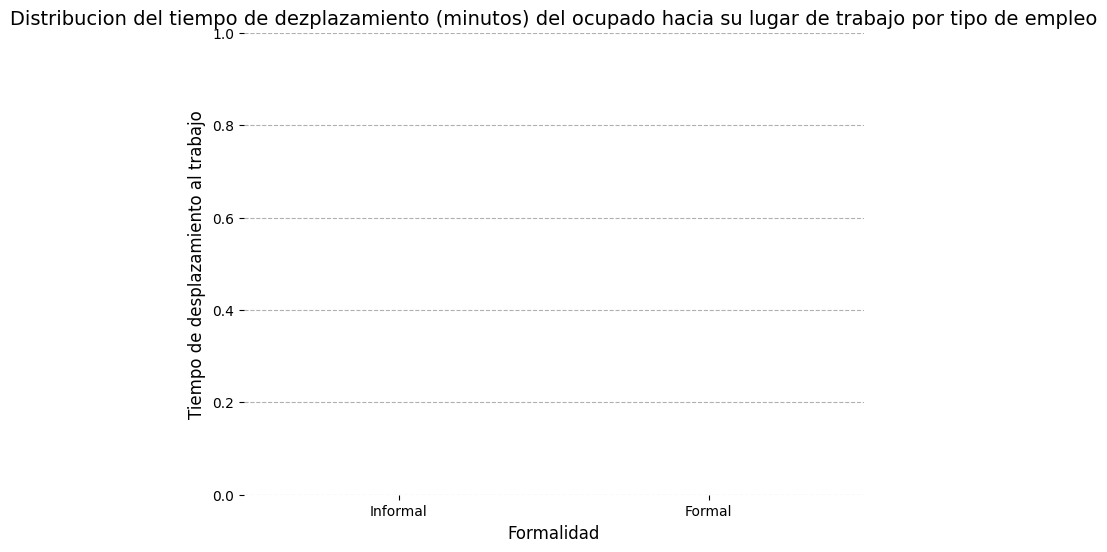

In [30]:

titulo_original = "Distribución del tiempo de dezplazamiento (minutos) del ocupado hacia su lugar de trabajo por tipo de empleo"

titulo = unidecode.unidecode(titulo_original) 


columna_tiempo = "Tiempo de desplazamiento hasta su sitio de trabajo"

mapeo_formalidad = {0: 'Informal', 1: 'Formal'}
datos3['formalidad_etiqueta'] = datos3['formalidad'].map(mapeo_formalidad)

colores = ['#F8766D', '#00BFC4']



plt.figure(figsize=(8, 6))


ax = sns.boxplot(
    data=datos3,
    x='formalidad_etiqueta',
    
    y=columna_tiempo, 
    palette=colores,
   
    order=['Informal', 'Formal']
)


plt.title(titulo, fontsize=14)
plt.xlabel("Formalidad", fontsize=12)
plt.ylabel("Tiempo de desplazamiento al trabajo", fontsize=12)


sns.despine(trim=True, left=True, bottom=True)
plt.grid(axis='y', linestyle='--')

plt.show()